## Stage 5 — Highlight Detection, Phase 1: Geometric Filter

## What the Geometric Filter does

Before any learning, we use pure math on the embeddings to find segments that are "interesting" — no training required. The idea: a highlight is a moment where all 3 modalities agree strongly AND the segment is locally different from its neighbors.

##The 3 geometric signals we compute

    Signal 1: Cross-modal Coherence
    How well do vision, audio, and text agree with each other?
    High coherence = all modalities tell the same story = meaningful moment

    Signal 2: Local Novelty
    How different is this segment from the ones around it?
    High novelty = something changed = potential highlight boundary

    Signal 3: Temporal Saliency
    How different is this segment from the global video average?
    High saliency = this moment stands out from the whole video

---



In [2]:
# ── CELL 1: Mount Drive & Configure Paths ────────────────────────────────
import sys, os
from google.colab import drive

drive.mount('/content/drive')

PROJECT_ROOT   = "/content/drive/MyDrive/PFA"
IMAGEBIND_ROOT = "/content/drive/MyDrive/PFA/ImageBind"
LIB_ROOT       = "/content/drive/MyDrive/PFA/ImageBind/ImageBind"

for p in [LIB_ROOT, IMAGEBIND_ROOT, PROJECT_ROOT]:
    if p not in sys.path:
        sys.path.insert(0, p)

INPUT_DIR  = os.path.join(PROJECT_ROOT, "data")
OUTPUT_DIR = os.path.join(IMAGEBIND_ROOT, "results")
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_VIDEO = "Obama_Yes_we_can.mp4"
VIDEO_PATH   = os.path.join(INPUT_DIR, TARGET_VIDEO)
VIDEO_STEM   = os.path.splitext(TARGET_VIDEO)[0]

TEXTS_PATH   = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_segment_texts.json")
EMB_PATH     = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_embeddings_final.npz")

print(f"Input : {INPUT_DIR}")
print(f"Output: {OUTPUT_DIR}")

Mounted at /content/drive
Input : /content/drive/MyDrive/PFA/data
Output: /content/drive/MyDrive/PFA/ImageBind/results


## Module-based execution (resumed)

This section uses the Python package in `Multimodal/Geometric_Filter` instead of redefining functions in notebook cells.
You can test `window_size=1` (segment), `2` (pair), `3` (triplet), or any valid integer up to the number of segments.

In [3]:
import os
import sys
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Resolve package path for local VS Code and Colab usage.
if "PROJECT_ROOT" in globals():
    MULTIMODAL_ROOT = os.path.join(PROJECT_ROOT, "Multimodal")
else:
    MULTIMODAL_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if MULTIMODAL_ROOT not in sys.path:
    sys.path.insert(0, MULTIMODAL_ROOT)

from Geometric_Filter import (
    get_highlights_by_window,
    rerank_filtered_highlights,
    save_geo_scores,
    save_top_segments,
)

print("Multimodal root:", MULTIMODAL_ROOT)

Multimodal root: /content/drive/MyDrive/PFA/Multimodal


In [4]:
# Load Stage 4 outputs and per-modality embeddings.
UNIFIED_PATH = os.path.join(OUTPUT_DIR, f"{VIDEO_STEM}_unified_final.npz")

npz = np.load(UNIFIED_PATH, allow_pickle=True)
unified = torch.tensor(npz["unified"])      # [N, D]
times = npz["times"]                         # [N, 2]
texts = npz["raw_text"]                      # [N]
trust = torch.tensor(npz["text_trust"])      # [N]

emb_npz = np.load(EMB_PATH, allow_pickle=True)
V = F.normalize(torch.tensor(emb_npz["vision"]), dim=-1)
A = F.normalize(torch.tensor(emb_npz["audio"]), dim=-1)
T = F.normalize(torch.tensor(emb_npz["text"]), dim=-1)

print("unified:", tuple(unified.shape))
print("V/A/T:", tuple(V.shape), tuple(A.shape), tuple(T.shape))
print("segments:", len(times))

unified: (88, 512)
V/A/T: (88, 1024) (88, 1024) (88, 1024)
segments: 88


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Run geometric filtering with generalized window size.
# Examples: 1=segment, 2=pair, 3=triplet, 4+=larger windows.
WINDOW_SIZE = 3
CONTEXT_WINDOW = 5
TOP_K = 20
MIN_GAP_S = 2.0

W_COHERENCE = 0.5
W_NOVELTY = 0.3
W_SALIENCY = 0.2

results, scores = get_highlights_by_window(
    unified=unified,
    V=V,
    A=A,
    T=T,
    trust=trust,
    times=times,
    texts=texts,
    window_size=WINDOW_SIZE,
    context_window=CONTEXT_WINDOW,
    top_k=TOP_K,
    min_gap_s=MIN_GAP_S,
    w_coherence=W_COHERENCE,
    w_novelty=W_NOVELTY,
    w_saliency=W_SALIENCY,
)

# Keep a clean copy before reranking for side-by-side investigation.
results_before_rerank = [dict(r) for r in results]

print("window_size:", WINDOW_SIZE)
print("returned highlights:", len(results))
print("score stats:")
print("  mean=%.3f std=%.3f min=%.3f max=%.3f" % (
    scores["geo_score"].mean().item(),
    scores["geo_score"].std().item(),
    scores["geo_score"].min().item(),
    scores["geo_score"].max().item(),
))

print("\nTop 10 highlights preview (before rerank):")
for r in results[:10]:
    t0, t1 = r["times"]
    print(
        "#%02d [%.1fs -> %.1fs] score=%.3f coh=%.2f nov=%.2f sal=%.2f | %s" % (
            r["rank"], t0, t1, r["geo_score"], r["coherence"], r["novelty"], r["saliency"], r["text"][:70]
        )
    )

window_size: 3
returned highlights: 20
score stats:
  mean=0.420 std=0.094 min=0.226 max=0.669

Top 10 highlights preview (before rerank):
#01 [1.0s -> 5.0s] score=0.719 coh=0.77 nov=0.73 sal=0.56 | Applause. a close up of a man in a suit and tie speaking into a microp
#02 [26.0s -> 30.0s] score=0.685 coh=1.00 nov=0.31 sal=0.47 | I do have one final ask of you. | I don't ask of you as your president
#03 [35.0s -> 39.0s] score=0.648 coh=0.74 nov=0.48 sal=0.68 | I'm asking you to believe. | You too believe. | Speech, Male speech, m
#04 [66.0s -> 70.0s] score=0.600 coh=0.69 nov=0.47 sal=0.57 | a creed at the core of every | the core of every American who's story 
#05 [74.0s -> 78.0s] score=0.570 coh=0.97 nov=0.07 sal=0.31 | Yes we did. | Yes we can. | Yes, we can
#06 [84.0s -> 88.0s] score=0.551 coh=0.30 nov=1.00 sal=0.50 | GEORGE B niche | Thank you. | Thank you.
#07 [58.0s -> 62.0s] score=0.550 coh=0.70 nov=0.36 sal=0.45 | That creep! | That cream reaffirmed. | reaffirmed by those who
#

In [7]:
# Rerank already-filtered highlights (post-filter stage).
# This consumes `results_before_rerank` from get_highlights_by_window.
R_W_GEO = 0.50
R_W_CENTRALITY = 0.20
R_W_DIVERSITY = 0.15
R_W_NARRATIVE = 0.15

results_reranked, rerank_details = rerank_filtered_highlights(
    results=results_before_rerank,
    unified=unified,
    w_geo=R_W_GEO,
    w_centrality=R_W_CENTRALITY,
    w_diversity=R_W_DIVERSITY,
    w_narrative=R_W_NARRATIVE,
)

print("Reranked highlights:", len(results_reranked))
print("\nTop 10 reranked highlights:")
for r in results_reranked[:10]:
    t0, t1 = r["times"]
    print(
        "#%02d [%.1fs -> %.1fs] rerank=%.3f geo=%.3f cent=%.2f div=%.2f narr=%.2f | %s" % (
            r["rank"],
            t0,
            t1,
            r["rerank_score"],
            r["base_geo_score"],
            r["centrality"],
            r["diversity"],
            r["narrative"],
            r["text"][:80],
        )
    )

Reranked highlights: 20

Top 10 reranked highlights:
#01 [26.0s -> 30.0s] rerank=0.779 geo=0.886 cent=0.68 div=0.75 narr=0.59 | I do have one final ask of you. | I don't ask of you as your president. | as you
#02 [66.0s -> 70.0s] rerank=0.687 geo=0.592 cent=0.62 div=1.00 narr=0.77 | a creed at the core of every | the core of every American who's story | American
#03 [74.0s -> 78.0s] rerank=0.662 geo=0.488 cent=0.60 div=0.99 narr=1.00 | Yes we did. | Yes we can. | Yes, we can
#04 [1.0s -> 5.0s] rerank=0.618 geo=1.000 cent=0.59 div=0.00 narr=0.00 | Applause. a close up of a man in a suit and tie speaking into a microphone | My 
#05 [60.0s -> 64.0s] rerank=0.543 geo=0.399 cent=0.63 div=0.70 narr=0.75 | reaffirmed by those who | by those who planted flags. | planted flags from forei
#06 [14.0s -> 18.0s] rerank=0.521 geo=0.381 cent=1.00 div=0.27 narr=0.60 | with you as a citizen. | a citizen. | Ed traced formation-
#07 [35.0s -> 39.0s] rerank=0.479 geo=0.759 cent=0.00 div=0.06 narr=0.61 | I

In [8]:
# Save outputs using Geometric_Filter I/O helpers.
geo_path = save_geo_scores(
    geo_score=scores["geo_score"],
    components=scores,
    times=times,
    texts=texts,
    output_dir=OUTPUT_DIR,
    video_stem=VIDEO_STEM,
    window_size=WINDOW_SIZE,
)

# Ensure reranked outputs exist even if reranker cell was skipped.
if "results_reranked" not in globals():
    results_reranked, rerank_details = rerank_filtered_highlights(
        results=results_before_rerank,
        unified=unified,
        w_geo=0.50,
        w_centrality=0.20,
        w_diversity=0.15,
        w_narrative=0.15,
    )

top_path_before = save_top_segments(
    results=results_before_rerank,
    scores=scores,
    output_dir=OUTPUT_DIR,
    video_stem=f"{VIDEO_STEM}_before_rerank",
    window_size=WINDOW_SIZE,
)

top_path_after = save_top_segments(
    results=results_reranked,
    scores=scores,
    output_dir=OUTPUT_DIR,
    video_stem=f"{VIDEO_STEM}_after_rerank",
    window_size=WINDOW_SIZE,
)

# Keep `top_path` pointing to post-rerank output for compatibility.
top_path = top_path_after

print("Saved geo scores:", geo_path)
print("Saved top highlights BEFORE rerank:", top_path_before)
print("Saved top highlights AFTER rerank:", top_path_after)

✓ Saved 88 segment scores → /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_geo_scores_triplet.npz
✓ Saved top 20 highlights → /content/drive/MyDrive/PFA/ImageBind/results/Obama_Yes_we_can_before_rerank_top20_triplet.npz

Rank     Start     End   Score    Coh    Nov    Sal  Text
────────────────────────────────────────────────────────────────────────────────────────────
  #1       1.0s    5.0s   0.719   0.77   0.73   0.56  Applause. a close up of a man in a suit and t
  #2      26.0s   30.0s   0.685   1.00   0.31   0.47  I do have one final ask of you. | I don't ask
  #3      35.0s   39.0s   0.648   0.74   0.48   0.68  I'm asking you to believe. | You too believe.
  #4      66.0s   70.0s   0.600   0.69   0.47   0.57  a creed at the core of every | the core of ev
  #5      74.0s   78.0s   0.570   0.97   0.07   0.31  Yes we did. | Yes we can. | Yes, we can
  #6      84.0s   88.0s   0.551   0.30   1.00   0.50  GEORGE B niche | Thank you. | Thank you.
  #7      58.0s   62.0s 

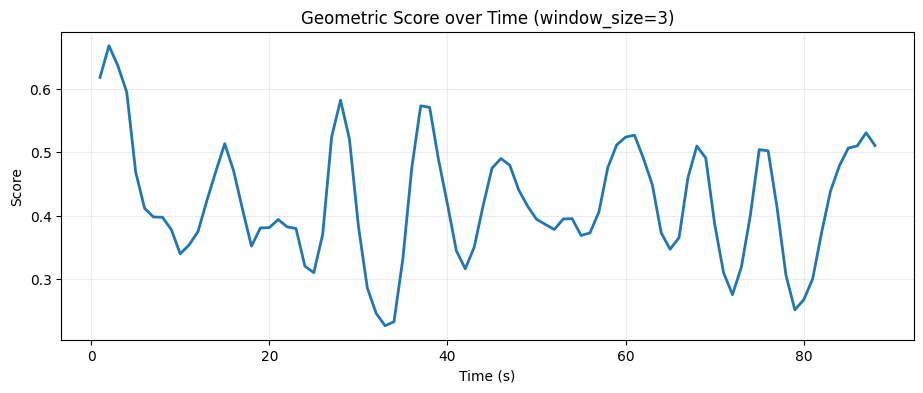

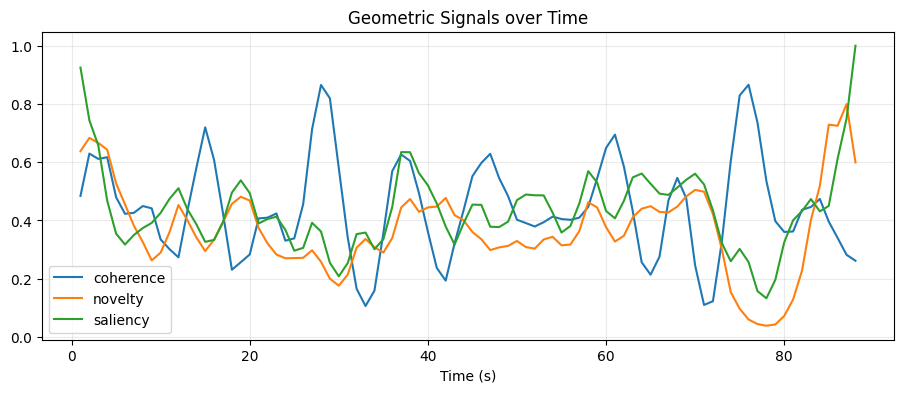

In [9]:
# Quick plots for score interpretation.
geo_npz = np.load(geo_path, allow_pickle=True)
plot_times = geo_npz["times"]
mid_times = (plot_times[:, 0] + plot_times[:, 1]) / 2.0

plt.figure(figsize=(11, 4))
plt.plot(mid_times, geo_npz["geo_score"], linewidth=2)
plt.title(f"Geometric Score over Time (window_size={WINDOW_SIZE})")
plt.xlabel("Time (s)")
plt.ylabel("Score")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(mid_times, geo_npz["coherence"], label="coherence")
plt.plot(mid_times, geo_npz["novelty"], label="novelty")
plt.plot(mid_times, geo_npz["saliency"], label="saliency")
plt.title("Geometric Signals over Time")
plt.xlabel("Time (s)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

Top highlights comparison (before vs after rerank):
Rank    Before score  After score            Before span             After span
------------------------------------------------------------------------------------------
#1             0.719        0.685 [  1.0,  5.0]s [ 26.0, 30.0]s
#2             0.685        0.600 [ 26.0, 30.0]s [ 66.0, 70.0]s
#3             0.648        0.570 [ 35.0, 39.0]s [ 74.0, 78.0]s
#4             0.600        0.719 [ 66.0, 70.0]s [  1.0,  5.0]s
#5             0.570        0.544 [ 74.0, 78.0]s [ 60.0, 64.0]s
#6             0.551        0.538 [ 84.0, 88.0]s [ 14.0, 18.0]s
#7             0.550        0.648 [ 58.0, 62.0]s [ 35.0, 39.0]s
#8             0.544        0.550 [ 60.0, 64.0]s [ 58.0, 62.0]s
#9             0.538        0.451 [ 14.0, 18.0]s [  6.0, 10.0]s
#10            0.504        0.483 [ 45.0, 49.0]s [ 12.0, 16.0]s


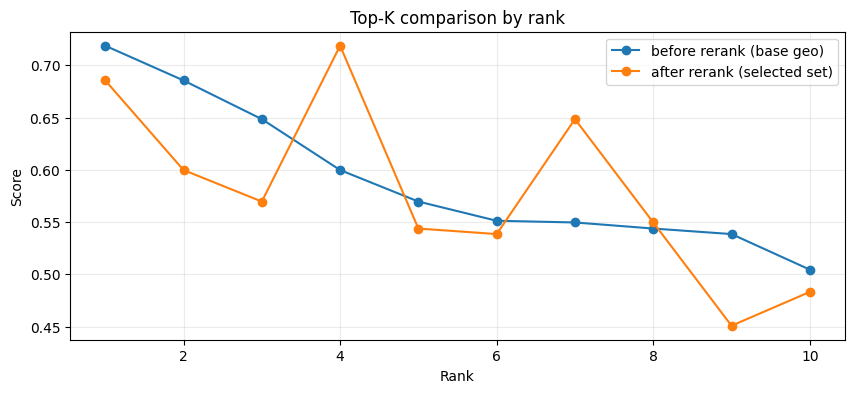

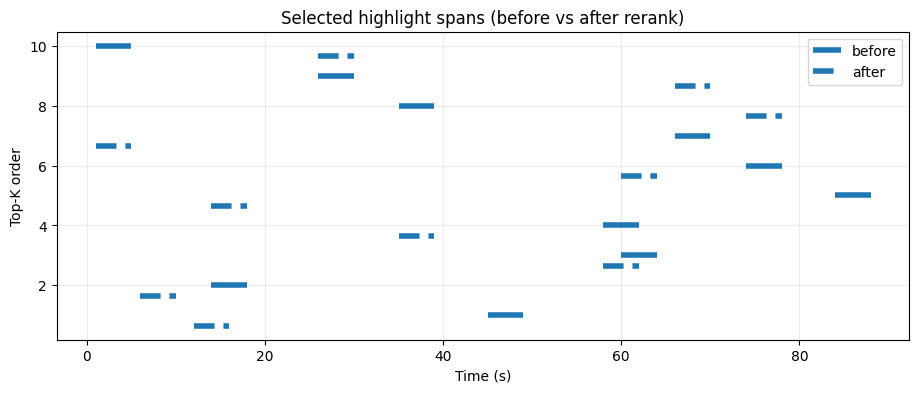

In [10]:
# Compare top results before vs after reranker.
before_npz = np.load(top_path_before, allow_pickle=True)
after_npz = np.load(top_path_after, allow_pickle=True)

k = min(10, len(before_npz["rank"]), len(after_npz["rank"]))

print("Top highlights comparison (before vs after rerank):")
print(f"{'Rank':<6} {'Before score':>13} {'After score':>12} {'Before span':>22} {'After span':>22}")
print("-" * 90)
for i in range(k):
    bs = float(before_npz["geo_score"][i])
    as_ = float(after_npz["geo_score"][i])
    bt = before_npz["times"][i]
    at = after_npz["times"][i]
    print(f"#{i+1:<5} {bs:>13.3f} {as_:>12.3f} [{bt[0]:>5.1f},{bt[1]:>5.1f}]s [{at[0]:>5.1f},{at[1]:>5.1f}]s")

# Score-by-rank view
plt.figure(figsize=(10, 4))
plt.plot(range(1, k + 1), before_npz["geo_score"][:k], marker="o", label="before rerank (base geo)")
plt.plot(range(1, k + 1), after_npz["geo_score"][:k], marker="o", label="after rerank (selected set)")
plt.title("Top-K comparison by rank")
plt.xlabel("Rank")
plt.ylabel("Score")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

# Timeline view of selected spans
plt.figure(figsize=(11, 4))
for i in range(k):
    b0, b1 = before_npz["times"][i]
    a0, a1 = after_npz["times"][i]
    yb = k - i
    ya = k - i - 0.35
    plt.hlines(yb, b0, b1, linewidth=4, label="before" if i == 0 else None)
    plt.hlines(ya, a0, a1, linewidth=4, linestyle="--", label="after" if i == 0 else None)

plt.title("Selected highlight spans (before vs after rerank)")
plt.xlabel("Time (s)")
plt.ylabel("Top-K order")
plt.grid(alpha=0.25)
plt.legend()
plt.show()